In [1]:
import pandas as pd
import os

# === CONFIGURATION ===
dir_path = 'Decon-COO-Results_Loy_COVID-MIS-C'
files = [
    'CIBERSORTx_Results.txt',
    'NNLS_GSE225221_cfrna_counts_CPM_GeneNames.txt',
    'nuSVR_Counts_Decon-COO-Results_Loy_COVID-MIS-C.txt',
    'QP_GSE225221_cfrna_counts_CPM_GeneNames_composition.txt',
    'TSP-BDa_Inner_100each_seed42_filtered_GSE225221_cfrna_counts_CPM_GeneNames_BayesPrism_renamed.txt',
    'TSP-HBA_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results.tsv',
    'TSP-HBA_Inner_100each_seed42_Loy_COVID-MIS-C_MuSiC.txt'
]

method_map = ['CIBERSORTx', 'MuSiC', 'QP', 'NNLS', 'BayesPrism', 'nuSVR', 'ReDeconv']

def normalize_to_100(df):
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].div(df[numeric_cols].sum(axis=1), axis=0) * 100
    return df

def clean_dataframe(df, file):
    if (
        file.endswith('BayesPrism_renamed.txt') or
        file.endswith('MuSiC.txt') or
        file.startswith('CIBERSORTx_Results') or
        file.endswith('ReDeconv_results.tsv')
    ):
        if file.startswith('CIBERSORTx_Results'):
            df = df.drop(columns=['P-value', 'Correlation', 'RMSE'], errors='ignore')
        df = normalize_to_100(df)

    elif file.startswith('QP') or file.startswith('NNLS'):
        df = df.drop(columns=[
            'RMSE-Composition', 'r-Composition',
            'RMSE-PredictedCounts', 'r-PredictedCounts'
        ], errors='ignore')

    return df.round(5)

def detect_method(filename):
    return next((m for m in method_map if m in filename), None)

# === FIRST PASS: COLLECT ALL CELL TYPES ===
all_celltypes = set()
temp_dfs = []
for file in files:
    file_path = os.path.join(dir_path, file)
    df = pd.read_csv(file_path, sep='\t', index_col=0)
    df = clean_dataframe(df, file)
    all_celltypes.update(df.columns)  # keep full set
    temp_dfs.append((file, df))

# Remove metadata columns from all_celltypes
all_celltypes = {c for c in all_celltypes if c not in ['Method', 'Sample']}

# === SECOND PASS: ENSURE CONSISTENT COLUMNS ===
all_results = []
for file, df in temp_dfs:
    # reindex to ensure all cell types present
    df = df.reindex(columns=list(all_celltypes))  # fill_value=None (default)

    method = detect_method(file)
    df['Method'] = method
    df['Sample'] = df.index
    all_results.append(df.reset_index(drop=True))

# === MERGE AND SAVE ===
merged_df = pd.concat(all_results, ignore_index=True)
output_file = os.path.join(dir_path, 'merged_normalised_results_Loy_COVID-MIS-C.txt')
merged_df.to_csv(output_file, sep='\t', index=False)
print(f"Merged results saved to: {output_file}")


Merged results saved to: Decon-COO-Results_Loy_COVID-MIS-C/merged_normalised_results_Loy_COVID-MIS-C.txt


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests

def pval_to_star(p):
    if pd.isna(p): return ""
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# ---------------- Files ----------------
decon_file = "Decon-COO-Results_Loy_COVID-MIS-C/merged_normalised_results_Loy_COVID-MIS-C.txt"
meta_file  = "GSE225221_cfrna_supplementary.tsv"

# ---------------- Load decon (CELL TYPE STRUCTURE) ----------------
decon = pd.read_csv(decon_file, sep="\t")

# Defensive: strip whitespace in column names (helps with odd headers)
decon.columns = decon.columns.str.strip()

# Ensure required columns exist
required = {"Sample", "Method"}
missing = required - set(decon.columns)
if missing:
    raise ValueError(f"Decon file missing columns: {missing}. Found: {list(decon.columns)[:10]} ...")

# ---------------- Load metadata ----------------
meta = pd.read_csv(meta_file, sep="\t")
meta.columns = meta.columns.str.strip()

meta_id_col = "cfrna_sample_id"   # from your metadata file
group_col   = "Diagnosis"
time_col    = "timepoint"

if meta_id_col not in meta.columns:
    raise ValueError(f"Metadata file missing '{meta_id_col}'. Found: {list(meta.columns)}")

# ---------------- Merge ----------------
merged = pd.merge(
    decon,
    meta,
    left_on="Sample",
    right_on=meta_id_col,
    how="inner"
)

print(f"Matched unique samples: {merged[meta_id_col].nunique()}")
print(f"Matched rows (sample × method): {merged.shape[0]}")

# ---------------- Keep 3 pathology categories ----------------
groups_to_keep = ["MIS-C", "COVID-19", "Control_Non-inflammatory"]
merged = merged[merged[group_col].isin(groups_to_keep)].copy()

# ---------------- Conditional timepoint filter (optional) ----------------
if time_col in merged.columns:
    mask_cases_acute  = merged[group_col].isin(["MIS-C", "COVID-19"]) & (merged[time_col] == "acute")
    mask_controls_all = merged[group_col].eq("Control_Non-inflammatory")
    merged = merged[mask_cases_acute | mask_controls_all].copy()

print("\nCounts after filters:")
print(merged[group_col].value_counts(dropna=False))

# ---------------- Identify CELL TYPE columns ----------------
# Everything except these is treated as a cell-type proportion column.
exclude_cols = {meta_id_col, group_col, time_col, "Sample", "Method"}
celltype_cols = [c for c in merged.columns if c not in exclude_cols]

# Ensure numeric
for c in celltype_cols:
    merged[c] = pd.to_numeric(merged[c], errors="coerce")

# Drop cell types that are entirely NaN (optional but helpful)
celltype_cols = [c for c in celltype_cols if not merged[c].isna().all()]
print(f"\nCell-type columns used: {len(celltype_cols)}")

# ---------------- Long format ----------------
long_df = merged.melt(
    id_vars=["Sample", "Method", group_col],
    value_vars=celltype_cols,
    var_name="CellType",
    value_name="Contribution"
).dropna(subset=["Contribution"])

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests

# ---------------- Settings ----------------
celltypes = [
    "neuron+neurons",
    "schwann + mesothelial/schwann",
    "astrocyte-containing group",
    "neutrophil",
    "b cell",
    "mature nk t cell/natural killer cell"
]

method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
path_order   = ["Control_Non-inflammatory", "COVID-19", "MIS-C"]

palette = {
    "Control_Non-inflammatory": "#4C72B0",
    "COVID-19": "#DD1C1A",
    "MIS-C": "#55A868"
}

alpha_sig = 0.05
BH_SCOPE = "within_tool"  # "global" or "within_tool"

def pval_to_star(p):
    if pd.isna(p): return ""
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def add_bracket(ax, x1, x2, y, text, height):
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.5, c="black")
    ax.text((x1+x2)/2, y+height, text, ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="black")

# ---------------- 0) Ordering + PLOT-ONLY merging ----------------
long_df = long_df.copy()
long_df["Method"] = pd.Categorical(long_df["Method"], categories=method_order, ordered=True)
long_df["Diagnosis"] = pd.Categorical(long_df["Diagnosis"], categories=path_order, ordered=True)

# Plot-only merge map: keep original CellType unchanged, create PlotCellType
plot_label = {}
plot_label.update({ct: "neuron+neurons" for ct in ["neuron", "neurons"]})
plot_label.update({ct: "schwann + mesothelial/schwann" for ct in ["schwann cell", "mesothelial cell/schwann cell"]})

plot_long_df = long_df.copy()
plot_long_df["PlotCellType"] = plot_long_df["CellType"].map(plot_label).fillna(plot_long_df["CellType"])

# Sum contributions within each sample × method × diagnosis × PlotCellType
plot_long_df = (
    plot_long_df
    .groupby(["Sample", "Method", "Diagnosis", "PlotCellType"], as_index=False)["Contribution"]
    .sum()
)

# ---------------- 1) Recompute stats on the merged plotting categories ----------------
min_n_per_group = 2
results = []

for (tool, ct), df_sub in plot_long_df.groupby(["Method", "PlotCellType"]):
    arrays = {
        g: sub["Contribution"].values
        for g, sub in df_sub.groupby("Diagnosis")
        if len(sub) >= min_n_per_group
    }
    present = sorted(arrays.keys())
    if len(present) < 2:
        continue

    kw_p = np.nan
    if len(present) >= 3:
        try:
            kw_p = kruskal(*[arrays[g] for g in present]).pvalue
        except ValueError:
            kw_p = np.nan

    for g1, g2 in combinations(present, 2):
        v1, v2 = arrays[g1], arrays[g2]
        med1, med2 = np.median(v1), np.median(v2)
        delta = med2 - med1
        pval = mannwhitneyu(v1, v2, alternative="two-sided").pvalue

        direction = f"{g2} > {g1}" if delta > 0 else (f"{g1} > {g2}" if delta < 0 else "Equal medians")

        results.append({
            "Method": tool,
            "PlotCellType": ct,
            "Overall_Kruskal_p": kw_p,
            "Group1": g1,
            "Group2": g2,
            "pval": pval,
            "Median_Group1": med1,
            "Median_Group2": med2,
            "Delta_Group2_minus_Group1": delta,
            "Direction": direction,
            "n_Group1": len(v1),
            "n_Group2": len(v2),
        })

plot_results_df = pd.DataFrame(results)

# BH correction
plot_results_df["pval_BH"] = np.nan
if not plot_results_df.empty:
    if BH_SCOPE == "global":
        valid = plot_results_df["pval"].dropna()
        _, p_corr, _, _ = multipletests(valid, method="fdr_bh")
        plot_results_df.loc[valid.index, "pval_BH"] = p_corr
    elif BH_SCOPE == "within_tool":
        for tool, idx in plot_results_df.groupby("Method").groups.items():
            valid = plot_results_df.loc[idx, "pval"].dropna()
            if len(valid) == 0:
                continue
            _, p_corr, _, _ = multipletests(valid, method="fdr_bh")
            plot_results_df.loc[valid.index, "pval_BH"] = p_corr

PVAL_COL = "pval_BH" if "pval_BH" in plot_results_df.columns else "pval"

# ---------------- 2) Print significant comparisons (merged plotting categories) ----------------
sig = plot_results_df[
    plot_results_df["PlotCellType"].isin(celltypes) &
    plot_results_df["Method"].isin(method_order) &
    (plot_results_df[PVAL_COL] < alpha_sig)
].copy()

sig["Stars"] = sig[PVAL_COL].apply(pval_to_star)

print(f"\n=== Significant comparisons ({PVAL_COL} < {alpha_sig}) ===")
if sig.empty:
    print("None.")
else:
    sig = sig.sort_values(["PlotCellType", "Method", PVAL_COL])
    for _, r in sig.iterrows():
        arrow = "↑" if r.get("Delta_Group2_minus_Group1", 0) > 0 else "↓"
        delta_txt = f" | Δ={r['Delta_Group2_minus_Group1']:.3f} {arrow}" if "Delta_Group2_minus_Group1" in r else ""
        print(
            f"{r['PlotCellType'][:50]:50s} | {r['Method']:10s} | "
            f"{r['Group1']:24s} vs {r['Group2']:24s} | "
            f"p={r[PVAL_COL]:.3e} {r['Stars']:4s}{delta_txt}"
        )

# ---------------- 3) Plotting ----------------
sns.set(style="white", context="talk")

hue_offsets = {
    path_order[0]: -0.25,
    path_order[1]:  0.00,
    path_order[2]:  0.25
}

for ct in celltypes:
    df_t = plot_long_df[
        (plot_long_df["PlotCellType"] == ct) &
        (plot_long_df["Method"].isin(method_order)) &
        (plot_long_df["Diagnosis"].isin(path_order))
    ].copy()

    df_t["Method"] = pd.Categorical(df_t["Method"], categories=method_order, ordered=True)
    df_t["Diagnosis"] = pd.Categorical(df_t["Diagnosis"], categories=path_order, ordered=True)

    if df_t.empty:
        print(f"Skipping (no data): {ct}")
        continue

    plt.figure(figsize=(14, 6))
    ax = sns.boxplot(
        data=df_t,
        x="Method",
        y="Contribution",
        hue="Diagnosis",
        hue_order=path_order,
        order=method_order,
        palette=palette,
        dodge=True,
        showfliers=False
    )

    sns.stripplot(
        data=df_t,
        x="Method",
        y="Contribution",
        hue="Diagnosis",
        hue_order=path_order,
        order=method_order,
        palette=palette,
        dodge=True,
        jitter=True,
        alpha=0.6,
        linewidth=0.5,
        size=4,
        ax=ax
    )

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:3],
        labels[:3],
        title="Pathology",
        frameon=False,
        bbox_to_anchor=(1.02, 0.5),
        loc="center left"
    )

    ax.set_title(ct, fontsize=16, fontweight="bold")
    ax.set_xlabel("Deconvolution method", fontsize=14, fontweight="bold")
    ax.set_ylabel("Contribution (%)", fontsize=14, fontweight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    sns.despine()
    ax.tick_params(axis="x", rotation=30)

    sig_t = sig[sig["PlotCellType"] == ct].copy()
    if not sig_t.empty:
        ymax = np.nanmax(df_t["Contribution"].values)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        base = ymax * 1.05
        step = ymax * 0.07

        xticks = ax.get_xticks()
        xticklabels = [t.get_text() for t in ax.get_xticklabels()]
        tool_to_x = dict(zip(xticklabels, xticks))

        stack_count = {m: 0 for m in method_order}

        for _, r in sig_t.sort_values(PVAL_COL).iterrows():
            tool = r["Method"]
            g1, g2 = r["Group1"], r["Group2"]
            if tool not in tool_to_x:
                continue
            if g1 not in hue_offsets or g2 not in hue_offsets:
                continue

            x_center = tool_to_x[tool]
            x1 = x_center + hue_offsets[g1]
            x2 = x_center + hue_offsets[g2]
            if x2 < x1:
                x1, x2 = x2, x1

            level = stack_count[tool]
            y = base + level * step
            add_bracket(ax, x1, x2, y, pval_to_star(r[PVAL_COL]), height=step * 0.25)
            stack_count[tool] += 1

        ax.set_ylim(0, base + (max(stack_count.values()) + 2) * step)

    plt.tight_layout()
    plt.show()


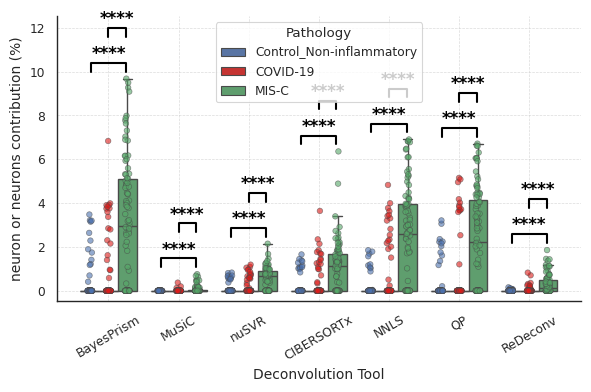

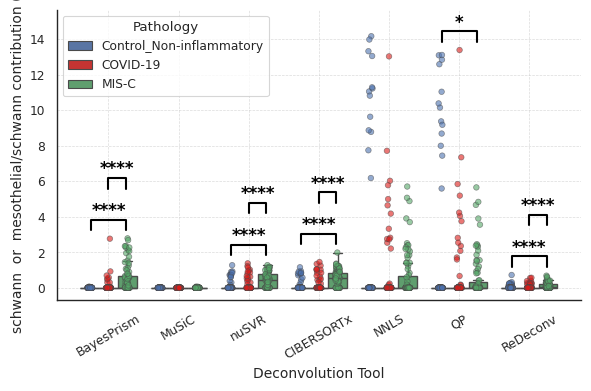

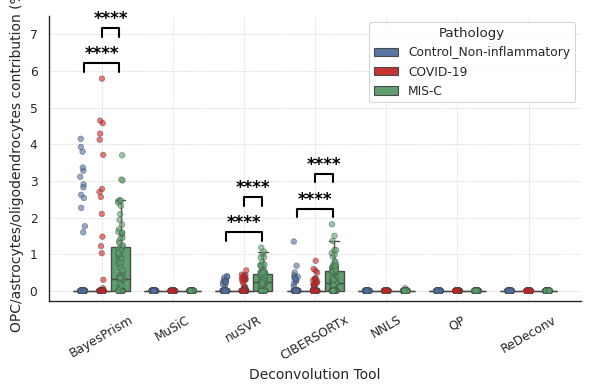

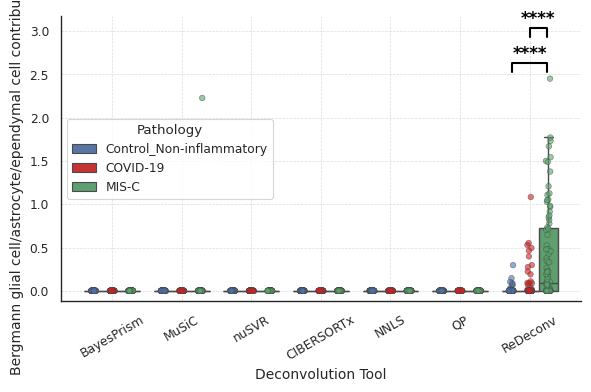

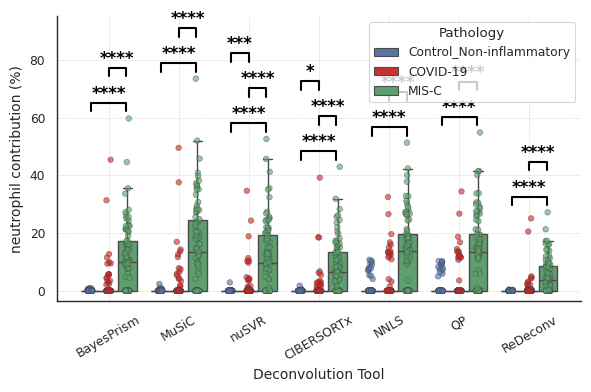

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl


mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# ---------------- 3) Plotting (MATCH TISSUE STYLE) ----------------
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.0)

# Offsets that match seaborn's dodge positions for 3 hues (approx)
hue_offsets = {
    path_order[0]: -0.25,
    path_order[1]:  0.00,
    path_order[2]:  0.25
}

for ct in celltypes:
    df_t = plot_long_df[
        (plot_long_df["PlotCellType"] == ct) &
        (plot_long_df["Method"].isin(method_order)) &
        (plot_long_df["Diagnosis"].isin(path_order))
    ].copy()

    df_t["Method"] = pd.Categorical(df_t["Method"], categories=method_order, ordered=True)
    df_t["Diagnosis"] = pd.Categorical(df_t["Diagnosis"], categories=path_order, ordered=True)

    if df_t.empty:
        print(f"Skipping (no data): {ct}")
        continue

    plt.figure(figsize=(6, 4))
    ax = sns.boxplot(
        data=df_t,
        x="Method",
        y="Contribution",
        hue="Diagnosis",
        hue_order=path_order,
        order=method_order,
        palette=palette,
        dodge=True,
        showfliers=False
    )

    sns.stripplot(
        data=df_t,
        x="Method",
        y="Contribution",
        hue="Diagnosis",
        hue_order=path_order,
        order=method_order,
        palette=palette,
        dodge=True,
        jitter=True,
        alpha=0.6,
        linewidth=0.5,
        size=4,
        ax=ax
    )

    def pretty_celltype(ct):
        return ct.replace("+", " or ")

    # keep a single legend (3 entries)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:3], labels[:3], title="Pathology", frameon=True)

    # --- Match tissue plot labeling ---
    # (No title; put cell type in y-axis label)
    ax.set_xlabel("Deconvolution Tool", fontsize=10)
    ax.set_ylabel(f"{pretty_celltype(ct)} contribution (%)", fontsize=10)

    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    sns.despine()
    ax.tick_params(axis="x", rotation=30)

    # ---- Add brackets (MATCH TISSUE METHOD-LOCAL STACKING) ----
    sig_t = sig[sig["PlotCellType"] == ct].copy()
    if not sig_t.empty:
        # Use axis range to define spacing in DATA units
        y0, y1 = ax.get_ylim()
        yr = max(y1 - y0, 1e-6)
        step = 0.15 * yr          # vertical gap between bracket levels
        height = 0.25 * step      # bracket "tick" height
        pad = 0.03 * yr           # padding above the data for that method

        # x positions for each method
        xticks = ax.get_xticks()
        xticklabels = [t.get_text() for t in ax.get_xticklabels()]
        tool_to_x = dict(zip(xticklabels, xticks))

        # stacking per method
        stack_count = {m: 0 for m in method_order}
        tool_top_y = {m: -np.inf for m in method_order}

        for _, r in sig_t.sort_values(PVAL_COL).iterrows():
            tool = r["Method"]
            g1, g2 = r["Group1"], r["Group2"]

            if tool not in tool_to_x or g1 not in hue_offsets or g2 not in hue_offsets:
                continue

            # method-local ymax
            tool_ymax = df_t.loc[df_t["Method"] == tool, "Contribution"].max()
            if not np.isfinite(tool_ymax):
                tool_ymax = 0.0

            level = stack_count[tool]
            y = tool_ymax + pad + level * step

            x_center = tool_to_x[tool]
            x1 = x_center + hue_offsets[g1]
            x2 = x_center + hue_offsets[g2]
            if x2 < x1:
                x1, x2 = x2, x1

            add_bracket(ax, x1, x2, y, pval_to_star(r[PVAL_COL]), height=height)

            stack_count[tool] += 1
            tool_top_y[tool] = max(tool_top_y[tool], y + height)

        # expand ylim only as needed (don’t force to 0)
        global_top = max([v for v in tool_top_y.values() if np.isfinite(v)] + [y1])
        ax.set_ylim(y0, max(y1, global_top + 0.05 * yr))

    plt.tight_layout()

    # --- Save SVG like tissue plotting ---
    safe_ct = "".join([c if c.isalnum() or c in "._-+" else "_" for c in ct])
    plt.savefig(f"{safe_ct}_Contribution_by_Pathology.svg", format="svg", bbox_inches="tight")

    plt.show()
    plt.close()
